# 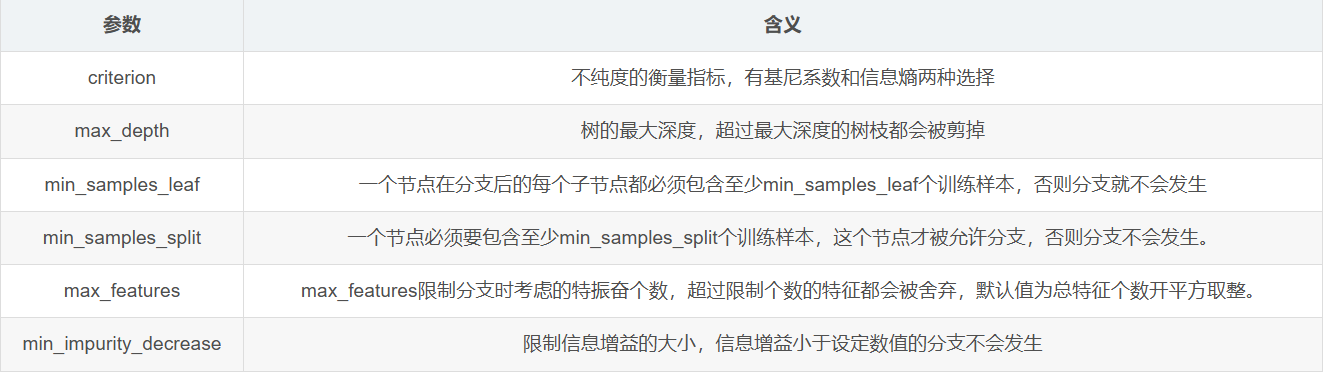

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

# 数据预处理 

In [ ]:
df = pd.read_excel(r"D:\桌面\随机森林\Machine Learning date.xlsx",sheet_name='normalization')
X = df[['TOTLE', 'IF-PP-PLA-film', 'IF-PP-PLA-injection', 'IF-PP-PLA-other', 'IF-PP-PLA-fiber', 'IF-PP-PHA-injection', 'IF-PP-PHA-woven-goods', 'IF-PP-PBS-film', 'IF-PP-PBS-injection', 'IF-PP-TPS-film',
        'IF-PE-PLA-film', 'IF-PE-PLA-STP', 'IF-PE-PBAT-film-(P)', 'IF-PE-PBAT-film-(A)', 'IF-PE-PHA-Woven-goods', 'IF-PVC-PHA-injection', 'IF-PVC-PHA-woven-goods', 'IF-PS-PLA-STP',
        'IF-PS-PHA-STP', 'IF-PS-PHA-foam-plastics', 'IF-PS-TPS-STP', 'IF-PET-PLA-bottle', 'IF-PET-PLA-fiber', 'IF-PET-PHA-bottle', 'SS-AD', 'SS-compost', 'SS-incineration', 'SS-landfill', '1-PBS', '1-PBAT',
        '1-PHA', '1-PLA', '1-TPS', '1-PET', '1-PP', '1-PS', '1-PVC', '1-PE', 'Incineration', 'landfill', 'Recycling', 'AD', 'compost', 'incineration']]
X = X.dropna()  #删除缺失值的行
y = X['TOTLE']
X = X[[ 'IF-PP-PLA-film', 'IF-PP-PLA-injection', 'IF-PP-PLA-other', 'IF-PP-PLA-fiber', 'IF-PP-PHA-injection', 'IF-PP-PHA-woven-goods', 'IF-PP-PBS-film', 'IF-PP-PBS-injection', 'IF-PP-TPS-film',
        'IF-PE-PLA-film', 'IF-PE-PLA-STP', 'IF-PE-PBAT-film-(P)', 'IF-PE-PBAT-film-(A)', 'IF-PE-PHA-Woven-goods', 'IF-PVC-PHA-injection', 'IF-PVC-PHA-woven-goods', 'IF-PS-PLA-STP',
        'IF-PS-PHA-STP', 'IF-PS-PHA-foam-plastics', 'IF-PS-TPS-STP', 'IF-PET-PLA-bottle', 'IF-PET-PLA-fiber', 'IF-PET-PHA-bottle', 'SS-AD', 'SS-compost', 'SS-incineration', 'SS-landfill', '1-PBS', '1-PBAT',
        '1-PHA', '1-PLA', '1-TPS', '1-PET', '1-PP', '1-PS', '1-PVC', '1-PE', 'Incineration', 'landfill', 'Recycling', 'AD', 'compost', 'incineration']]
X = np.array(X)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
rfc = RandomForestRegressor(n_estimators=100,random_state=90)
score_pre = cross_val_score(rfc,X_train,y_train,cv=10).mean()#交叉验证的分类默认scoring='accuracy'
score_pre

np.float64(0.4529661591776738)

In [4]:
rfc.fit(X_train, y_train)

RandomForestRegressor(random_state=90)

In [5]:
y_pred = rfc.predict(X_test)

In [6]:
r2 = r2_score(y_test, y_pred)
print('R2:{0}'.format(r2))

MSE = mean_squared_error(y_test, y_pred)
print('MSE:{0}'.format(MSE))

MAE = mean_absolute_error(y_test, y_pred)
print("MAE:", MAE)


R2:0.8084689328455694
MSE:0.004119062610872971
MAE: 0.044031008584373636


# 调整参数

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# 定义回归模型
rfc = RandomForestRegressor(random_state=90)

# 定义超参数搜索空间
param_grid = {
    'n_estimators': [100, 200, 300],   # 增加树的数量
    'max_depth': [None, 10, 20, 30],    # 最大深度，防止过拟合
    'min_samples_split': [2, 5, 10],    # 最小样本分裂数
    'min_samples_leaf': [1, 2, 4],      # 最小叶子节点样本数
    'max_features': ['sqrt', 'log2', None],  # 正确的特征选择方法
}

# 使用 GridSearchCV 进行超参数调优，cv=10 表示 10 折交叉验证
GS = GridSearchCV(rfc, param_grid, cv=10, n_jobs=-1, verbose=2)

# 训练模型
GS.fit(X_train, y_train)

# 输出最佳超参数
print("Best Parameters: ", GS.best_params_)

# 使用最优参数的模型进行预测
best_rfc = GS.best_estimator_
y_pred = best_rfc.predict(X_test)

# 计算 R² 分数
r2 = r2_score(y_test, y_pred)
print("R²:", r2)


Fitting 10 folds for each of 324 candidates, totalling 3240 fits
Best Parameters:  {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
R²: 0.8093038182658718


In [7]:
rfc = RandomForestRegressor(n_estimators=100,random_state=90,max_depth = 10,min_samples_leaf = 1, min_samples_split = 10)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

def metrics_sklearn(y_valid, y_pred_):
    """模型效果评估"""
    r2 = r2_score(y_valid, y_pred_)
    print('R2:{0}'.format(r2))

    MSE = mean_squared_error(y_valid, y_pred_)
    print('MSE:{0}'.format(MSE))

    MAE = mean_absolute_error(y_valid, y_pred)
    print("MAE:", MAE)
"""模型效果评估"""
metrics_sklearn(y_test, y_pred)

R2:0.8093038182658718
MSE:0.004101107584723831
MAE: 0.043916094942152005


# 拟合效果+SHAP

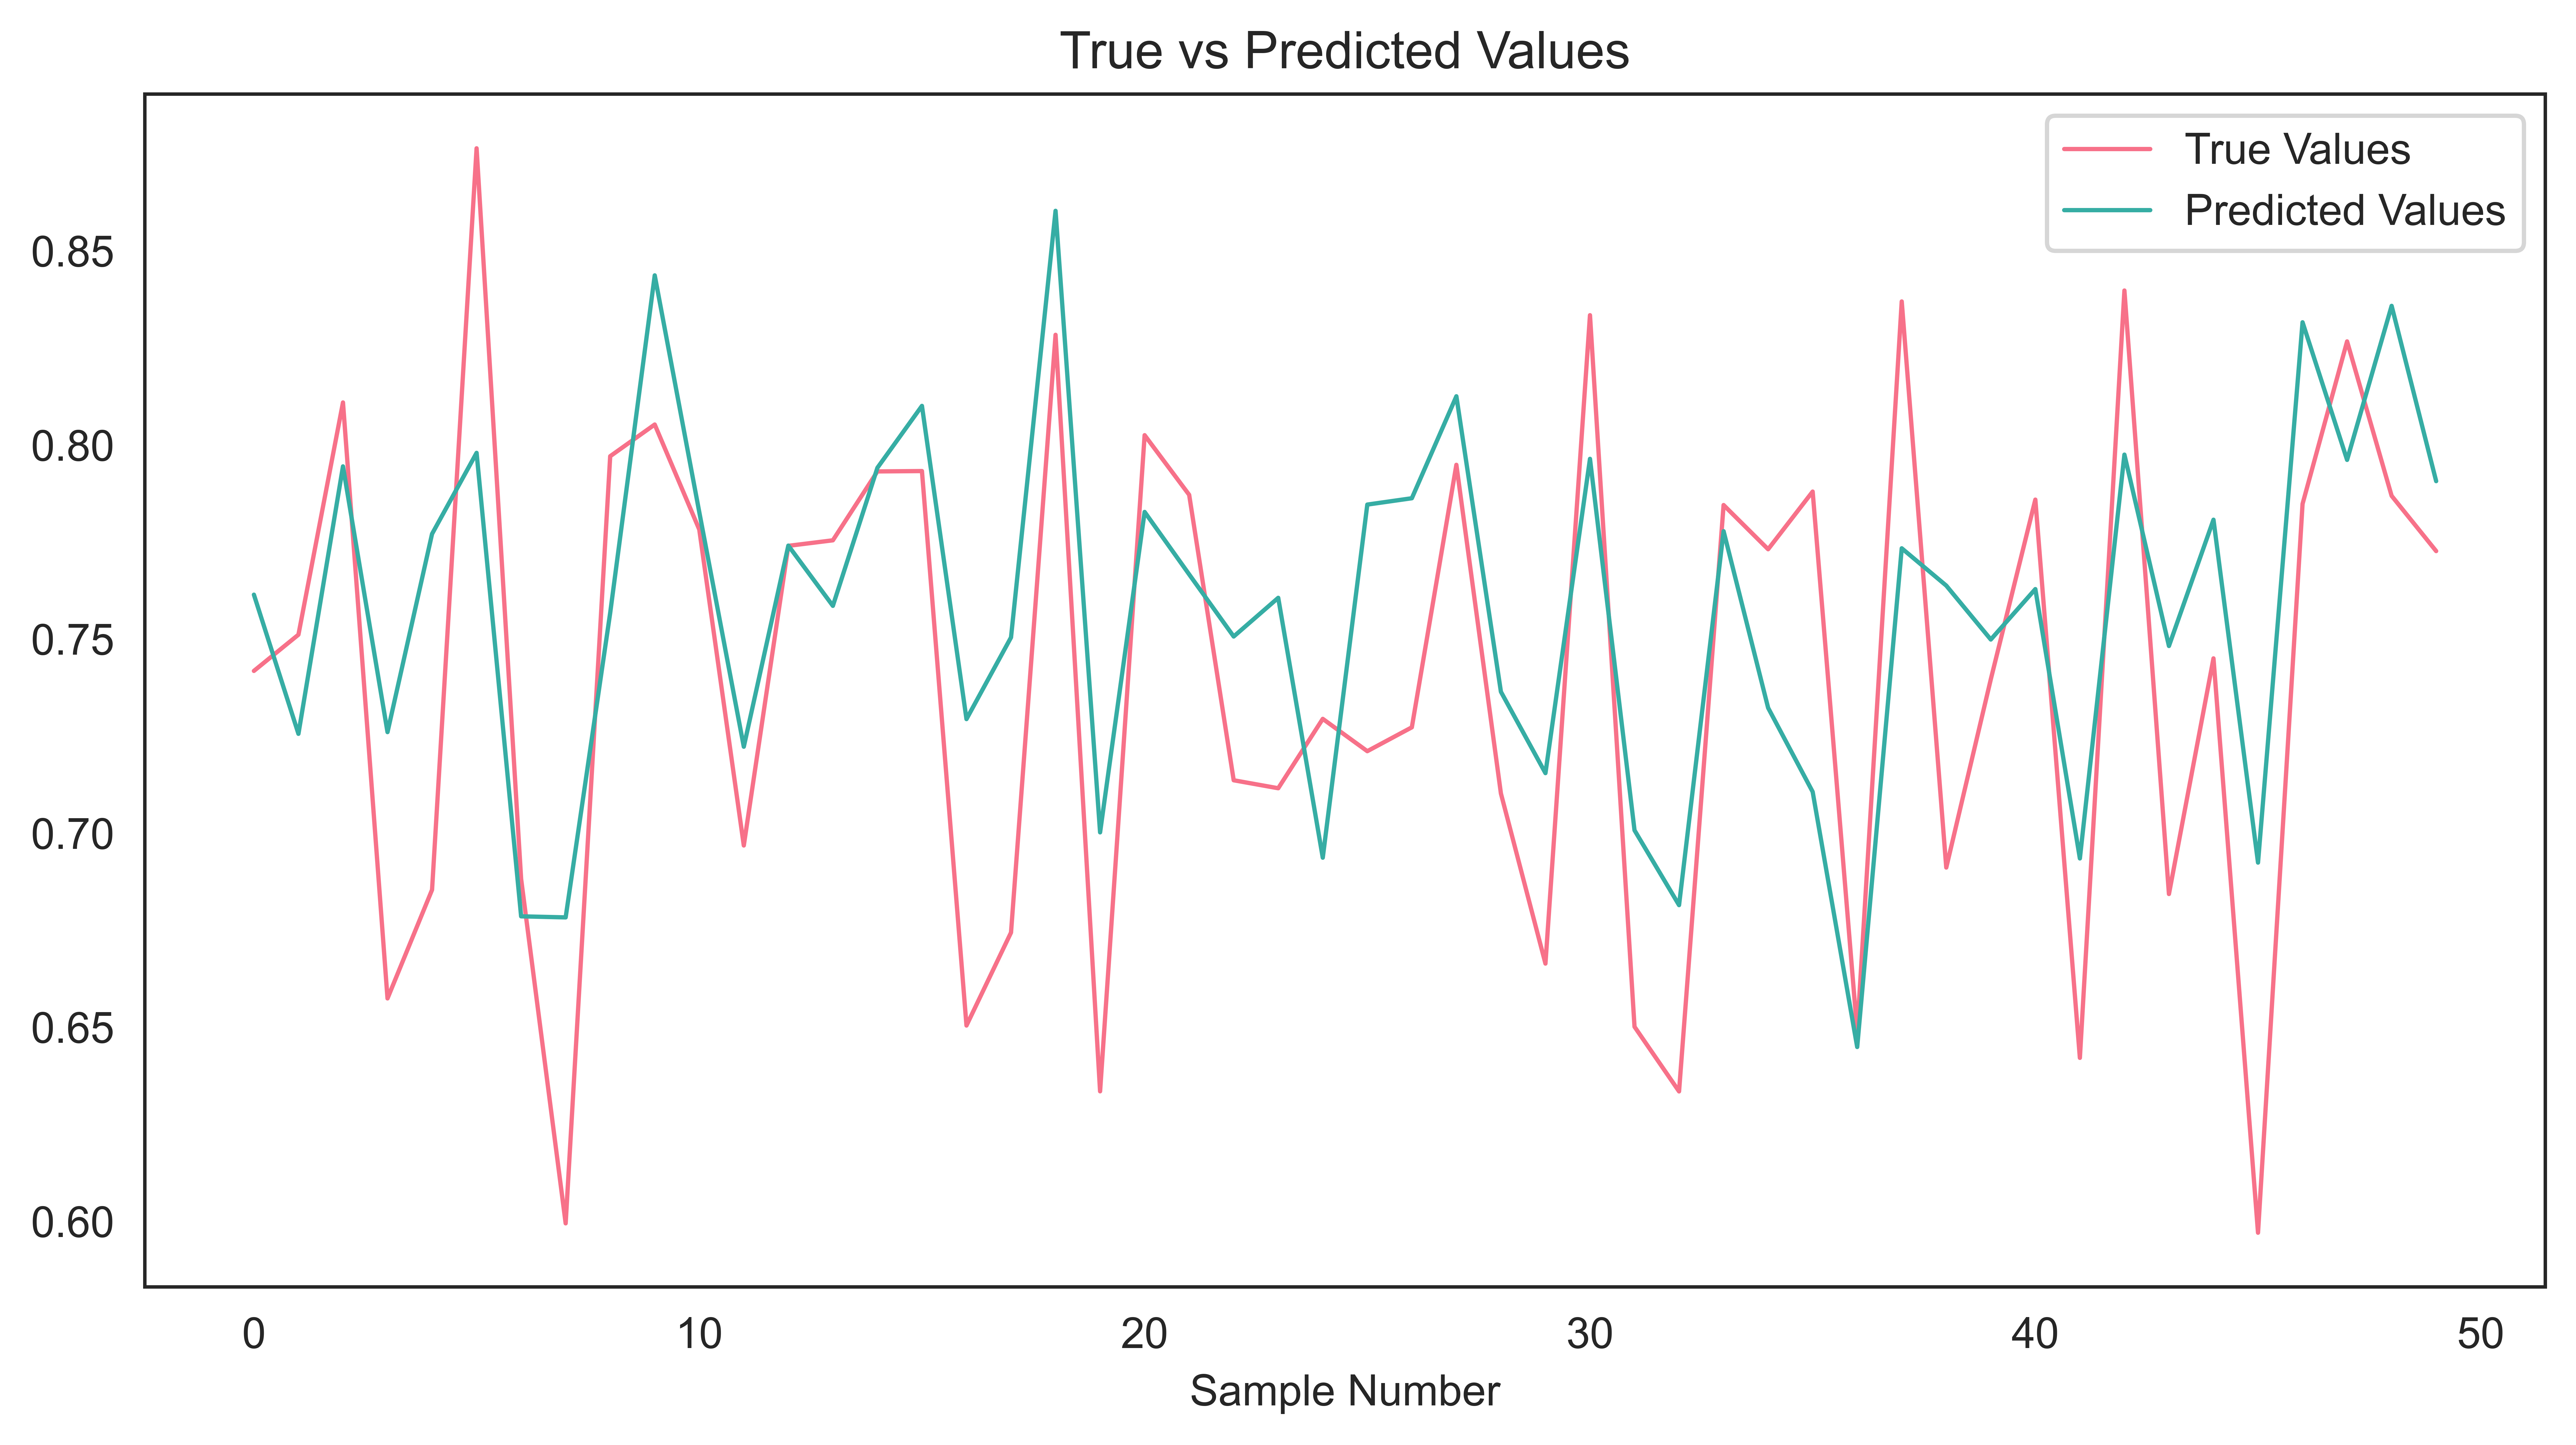

In [9]:
import seaborn as sns
sns.set_style("white") 
palette = sns.color_palette("husl", n_colors=2) 
 
# 设置画布大小和分辨率
plt.figure(figsize=(10, 5), dpi=1080)
 
# 绘制测试集数据的真实值和模型预测值的折线图
x_ax = range(len(y_test[:50]))

plt.plot(x_ax, y_test[:50], label="True Values", color=palette[0], linewidth=1) # 真实值
plt.plot(x_ax, y_pred[:50], label="Predicted Values", color=palette[1], linewidth=1) # 预测值
 
# 添加标题和标签
plt.title("True vs Predicted Values")
plt.xlabel("Sample Number")
# plt.ylabel("CO2 Emissions")
 
# 显示图例
plt.legend()
plt.savefig('True vs Predicted Values.png')
# 显示图形
plt.show()

c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


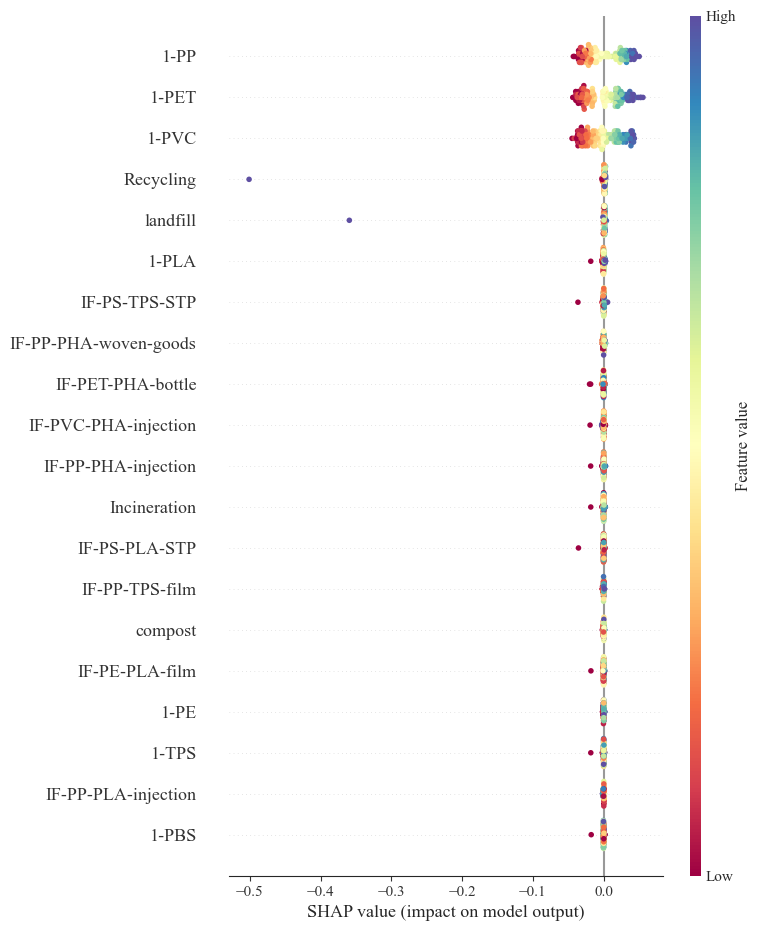

<Figure size 700x600 with 0 Axes>

In [15]:
import shap
import pandas as pd
feature_names = [ 'SR-PP-PLA-film', 'SR-PP-PLA-injection', 'SR-PP-PLA-other', 'SR-PP-PLA-fiber', 'SR-PP-PHA-injection', 'SR-PP-PHA-woven-goods', 'SR-PP-PBS-film', 'SR-PP-PBS-injection', 'SR-PP-TPS-film',
                 'SR-PE-PLA-film', 'SR-PE-PLA-STP', 'SR-PE-PBAT-film', 'SR-PE-PHA-Woven-goods', 'SR-PVC-PHA-injection', 'SR-PVC-PHA-woven-goods', 'SR-PS-PLA-STP',
                 'SR-PS-PHA-STP', 'SR-PS-PHA-foam-plastics', 'SR-PS-TPS-STP', 'SR-PET-PLA-bottle', 'SR-PET-PLA-fiber', 'SR-PET-PHA-bottle', ' EPR- Anaerobic digestion ', ' EPR-Compost', ' EPR-Incineration', ' EPR-Landfill', 'UCE-PBS', 'UCE-PBAT',
                 'UCE-PHA', 'UCE-PLA', 'UCE-TPS', 'UCE-PET', 'UCE-PP', 'UCE-PS', 'UCE-PVC', 'UCE-PE', ' UCE-Incineration', ' UCE-Landfill', ' UCE-Recycling', ' UCE-Anaerobic digestion', ' UCE-Compost'
]

X_test = pd.DataFrame(X_test, columns=feature_names)
# SHAP解析

explainer = shap.TreeExplainer(rfc)
# 计算 SHAP 值
shap_values = explainer.shap_values(X_test)

#设置字体和大小
plt.rcParams['font.family']='serif'
plt.rcParams['font.serif']= 'Times New Roman'
plt.rcParams['font.size']=13

# 配色有：viridis Spectral coolwarm RdYlGn RdYlBu RdBu RdGy PuOr BrBG PRGn PiYG
shap.summary_plot(shap_values, X_test,cmap='Spectral',max_display=20)
# 保存图形为高质量的图片文件
plt.gcf().set_size_inches(7,6)
plt.savefig('picture1.png',dpi=600,bbox_inches='tight')

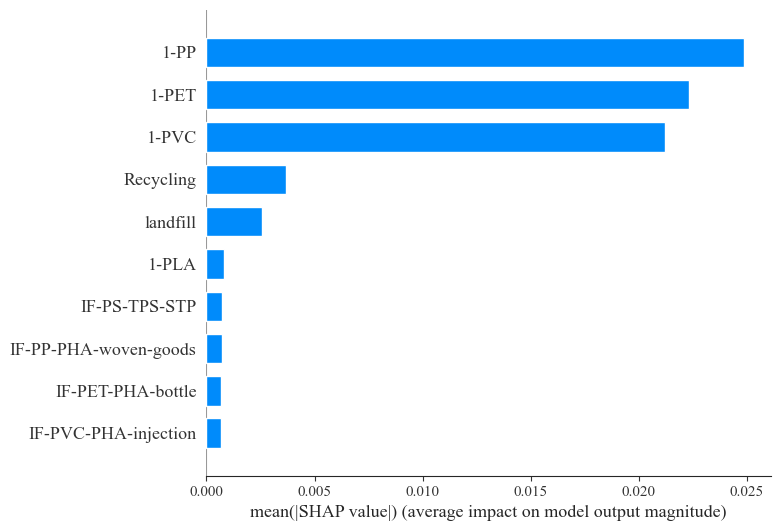

In [16]:
shap.summary_plot(shap_values, X_test,plot_type='bar',max_display=10)
# max_display=10是指最多显示10个指标

In [17]:
feature_importance = pd.DataFrame()

feature_importance['feature'] = feature_names

feature_importance['importance'] = np.abs(shap_values).mean(0)

feature_importance.sort_values('importance', ascending=False)

,feature,importance
33,1-PP,0.024874
32,1-PET,0.022347
35,1-PVC,0.021213
39,Recycling,0.003680
38,landfill,0.002576
30,1-PLA,0.000796
19,IF-PS-TPS-STP,0.000723
5,IF-PP-PHA-woven-goods,0.000702
22,IF-PET-PHA-bottle,0.000675
14,IF-PVC-PHA-injection,0.000664
